## 1. Загрузка данных и первичный анализ

### 1.1. Загрузка датасета

In [322]:
# Загрузите все необходимые библиотеки и датасет

import pandas as pd
import numpy as np
import os
# Выведите первые 5 строк датасета
df = pd.read_excel("./3_Concrete_Data.xls")
print(df.head())




   Cement (component 1)(kg in a m^3 mixture)  \
0                                      540.0   
1                                      540.0   
2                                      332.5   
3                                      332.5   
4                                      198.6   

   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  \
0                                                0.0       
1                                                0.0       
2                                              142.5       
3                                              142.5       
4                                              132.4       

   Fly Ash (component 3)(kg in a m^3 mixture)  \
0                                         0.0   
1                                         0.0   
2                                         0.0   
3                                         0.0   
4                                         0.0   

   Water  (component 4)(kg in a m^3 mixture)  \
0      

В датасете представлены числовые признаки, описывающие состав бетонной смеси: количество цемента, шлака, золы, воды, суперпластификатора, крупного и мелкого заполнителя, а также возраст бетона. Целевой переменной является прочность бетона на сжатие — Concrete compressive strength. Именно её необходимо предсказывать с помощью моделей машинного обучения.

### 1.2. Размерность и описательные статистики

In [323]:
# получите размерность датасета
print(df.shape)

(1030, 9)


In [324]:
# получите описательные статистики датасета
print(df.describe())

       Cement (component 1)(kg in a m^3 mixture)  \
count                                1030.000000   
mean                                  281.165631   
std                                   104.507142   
min                                   102.000000   
25%                                   192.375000   
50%                                   272.900000   
75%                                   350.000000   
max                                   540.000000   

       Blast Furnace Slag (component 2)(kg in a m^3 mixture)  \
count                                        1030.000000       
mean                                           73.895485       
std                                            86.279104       
min                                             0.000000       
25%                                             0.000000       
50%                                            22.000000       
75%                                           142.950000       
max                


В датасете 1030 наблюдений и 9 столбцов. Пропуски отсутствуют, признаки имеют разный масштаб, что потребует нормализации перед обучением модели.

## 2. Признаки с низкой вариацией

### 2.1. Количество уникальных значений

In [325]:
# посчитайте количество уникальных значений
# выведите количество уникальных значений по столбцам
print(df.nunique())

Cement (component 1)(kg in a m^3 mixture)                280
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    187
Fly Ash (component 3)(kg in a m^3 mixture)               163
Water  (component 4)(kg in a m^3 mixture)                205
Superplasticizer (component 5)(kg in a m^3 mixture)      155
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     284
Fine Aggregate (component 7)(kg in a m^3 mixture)        304
Age (day)                                                 14
Concrete compressive strength(MPa, megapascals)          938
dtype: int64


### 2.2. Поиск и удаление константных / почти константных признаков

In [326]:
# Найдите признаки с одной уникальной категорией
# Выведите их количество
counts = df.nunique()

to_del = counts[counts == 1].index

print("Признаки с одной уникальной категорией:")
print(list(to_del))

print("Количество таких признаков:", len(to_del))

Признаки с одной уникальной категорией:
[]
Количество таких признаков: 0


In [327]:
# Приведите код для удаления колонок с константными признаками
# Выведите обновленную размерность датасета
df.drop(columns=to_del, inplace=True)

print("Обновленная размерность датасета:", df.shape)

Обновленная размерность датасета: (1030, 9)


Комментарий:

*Объясните, почему эти признаки не полезны для модели.*
Константные признаки не содержат полезной информации, поскольку их значение одинаково для всех объектов в датасете. Из-за этого они не помогают модели выявлять различия между наблюдениями и строить зависимости, но при этом увеличивают объём данных и могут усложнять обучение. Поэтому такие признаки обычно удаляют на этапе предварительной обработки.

## 3. Дубликаты строк

### 3.1. Поиск дубликатов


In [328]:
# приведите код для поиска дубликатов строк
# выведите общее количество дубликатов строк в датасете
duplicates_count = df.duplicated().sum()

print("Количество дубликатов строк:", duplicates_count)

Количество дубликатов строк: 25


In [329]:
# При наличии дубликатов выведите первые 5 строк из повторяющихся значений
if duplicates_count > 0:
    print("Первые 5 строк из повторяющихся значений:")
    print(df[df.duplicated(keep=False)].head())

Первые 5 строк из повторяющихся значений:
    Cement (component 1)(kg in a m^3 mixture)  \
72                                      425.0   
77                                      425.0   
80                                      425.0   
83                                      362.6   
86                                      362.6   

    Blast Furnace Slag (component 2)(kg in a m^3 mixture)  \
72                                              106.3       
77                                              106.3       
80                                              106.3       
83                                              189.0       
86                                              189.0       

    Fly Ash (component 3)(kg in a m^3 mixture)  \
72                                         0.0   
77                                         0.0   
80                                         0.0   
83                                         0.0   
86                                         0.0

### 3.2. Удаление дубликатов

In [330]:
# Удалите дубликаты из датасета
# Проверьте размерность датасета после удаления дубликатов
df.drop_duplicates(inplace=True)

print("Размерность после удаления дубликатов:", df.shape)

Размерность после удаления дубликатов: (1005, 9)


Комментарий:

Дубликаты могут искажать обучение модели, так как повторяющиеся строки увеличивают влияние одних и тех же наблюдений. Из-за этого модель может переобучаться на повторяющихся данных и хуже обобщать зависимости на новых объектах. Поэтому дубликаты удаляются перед построением модели.


## 4. Выбросы

### 4.1. Исследование распределений (по выбору 2–3 признаков)

In [331]:
# Приведеите пример гистограммы минимум 3х признаков

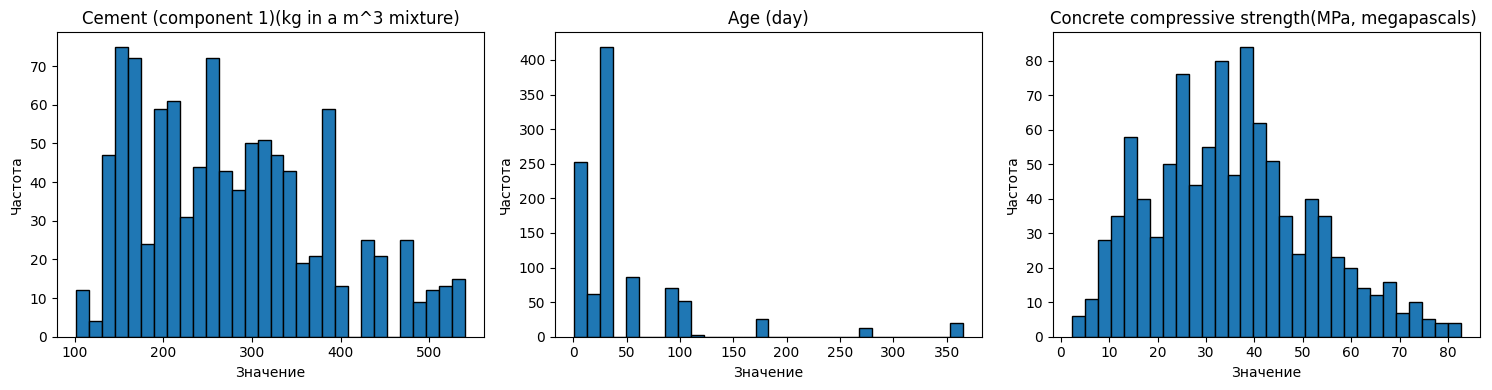

In [332]:
import matplotlib.pyplot as plt

features = [
    'Cement (component 1)(kg in a m^3 mixture)',
    'Age (day)',
    'Concrete compressive strength(MPa, megapascals) '
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=30, edgecolor='black')
    axes[i].set_title(feature)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

### 4.2. Определение выбросов (3σ или IQR)

In [333]:
# определите верхние и нижние пределы выбросов одним из способов для одного из признаков. 
import pandas as pd

# Для признака 'Age'
features = [
    'Age (day)',
    'Cement (component 1)(kg in a m^3 mixture)',
    'Water  (component 4)(kg in a m^3 mixture)'
]
sumOutliers = 0
for feature in features:
    q25 = df[feature].quantile(0.25)
    q75 = df[feature].quantile(0.75)
    iqr = q75 - q25

    lower = q25 - 1.5 * iqr
    upper = q75 + 1.5 * iqr

    outliers = df[(df[feature] < lower) | (df[feature] > upper)]
    sumOutliers += len(outliers)

    print(f"\nПризнак: {feature}")
    print(f"Нижняя граница: {lower:.2f}")
    print(f"Верхняя граница: {upper:.2f}")
    print(f"Количество выбросов: {len(outliers)}")


Признак: Age (day)
Нижняя граница: -66.50
Верхняя граница: 129.50
Количество выбросов: 59

Признак: Cement (component 1)(kg in a m^3 mixture)
Нижняя граница: -46.80
Верхняя граница: 586.48
Количество выбросов: 0

Признак: Water  (component 4)(kg in a m^3 mixture)
Нижняя граница: 127.12
Верхняя граница: 232.43
Количество выбросов: 15


In [334]:
# посчитайте количество выбросов

print(f"Количество выбросов: {sumOutliers}")

Количество выбросов: 74


*(Повторите аналогичную процедуру для двух других признаков.)*
Анализ выбросов выполнен для трёх признаков: возраста бетона, количества цемента и количества воды.

## 5. Пропуски в данных

### 5.1. Анализ пропусков

In [335]:
# посчитайте количество пропусков по столбцам
print(df.isnull().sum())

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64


### 5.2. Стратегии обработки пропусков

#### Стратегия 1: (например, удаление строк с пропусками)

In [336]:
# приведите код для удаления пропусков
# выведите размер датасета послед удаления пропусков
print(f"Размер ДО удаления: {df.shape}")
df.dropna(inplace=True)
print(f"Размер ПОСЛЕ удаления: {df.shape}")


Размер ДО удаления: (1005, 9)
Размер ПОСЛЕ удаления: (1005, 9)


#### Стратегия 2: (например, простая импутация средним / kNN / IterativeImputer)

In [337]:
# примените один из методов для замены пропущенных значений
from sklearn.impute import SimpleImputer

df_imputed = df.copy()
imputer = SimpleImputer(strategy='mean')
df_imputed[:] = imputer.fit_transform(df_imputed)

print("Пропуски после импутации:")
print(df_imputed.isnull().sum().sum())


Пропуски после импутации:
0


Комментарий:

Выбрана импутация средним значением, потому что этот метод простой и быстрый. Если бы в данных были пропуски, он позволил бы сохранить все строки без потери информации.

## 6. Построение и оценка моделей

### 6.1. Разбиение на обучающую и тестовую выборки

In [338]:
# импортируйте модуль из библиотеки sklearn для разбиения на обучающую и тестовую выборки
# разбейте все данные на тестовую и обучающую выборки
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Concrete compressive strength(MPa, megapascals) '])
y = df['Concrete compressive strength(MPa, megapascals) ']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


Размер обучающей выборки: (673, 8)
Размер тестовой выборки: (332, 8)


### 6.2. Модель 1: линейная регрессия

In [339]:
# обучите модель линейной регрессии и посчитайте MAE, RMSE, R2
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Линейная регрессия:")
print(f"MAE: {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R2: {r2_lr:.3f}")

Линейная регрессия:
MAE: 8.70
RMSE: 10.88
R2: 0.564


Комментарий:

Линейная модель продемонстрировала умеренное качество предсказания. Такой подход эффективен, когда зависимость между входными признаками и целевой переменной имеет преимущественно линейный характер. Однако для данной задачи этой модели недостаточно, так как прочность бетона, вероятно, зависит от признаков более сложным образом.

### 6.3. Модель 2: более сложная (например, RandomForestRegressor)

In [340]:
# обучите модель случайного леса и посчитайте MAE, RMSE, R2
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=1)
model_rf.fit(X_train, y_train)

# Предсказания
y_pred_rf = model_rf.predict(X_test)

# Метрики
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Случайный лес:")
print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R2: {r2_rf:.3f}")

Случайный лес:
MAE: 3.74
RMSE: 5.34
R2: 0.895


Комментарий:

Модель случайного леса показала более высокое качество по сравнению с линейной регрессией. Это объясняется тем, что она лучше учитывает сложные нелинейные связи между признаками и их совместное влияние на целевую переменную. Благодаря этому прогноз прочности бетона получается более точным.